<a href="https://colab.research.google.com/github/tomheston/blockchain-climate-framework/blob/main/notebooks/Fig%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

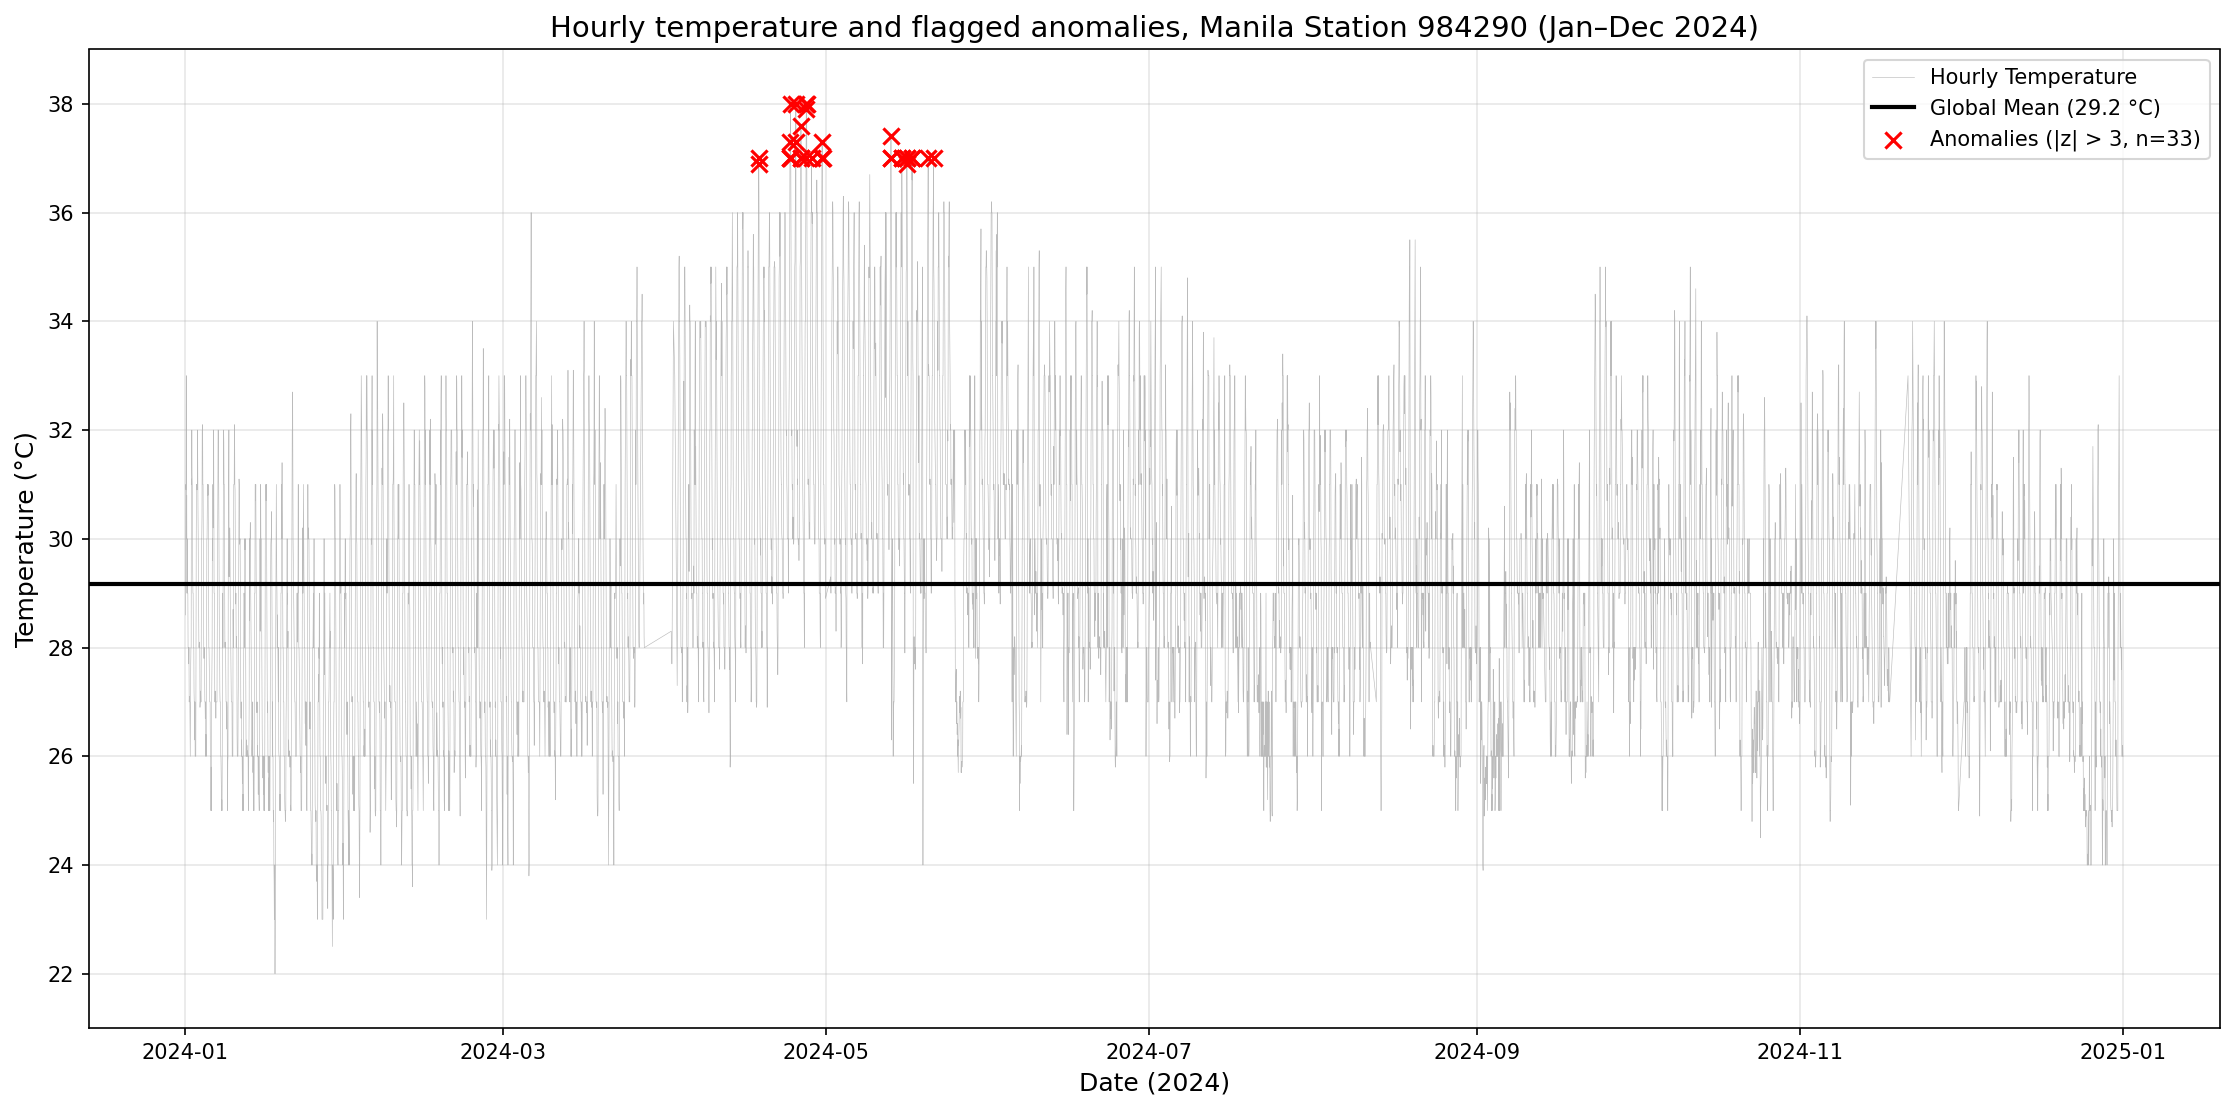

Anomalies: 33 (April: 21, May: 12)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Parse
data = []
with open('noaa_984290_2024.txt', 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) < 5:
            continue
        year, month, day, hour = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
        temp_raw = int(parts[4])
        if temp_raw == -9999:
            continue
        temp_c = temp_raw / 10.0
        dt = datetime(year, month, day, hour)
        data.append({'datetime': dt, 'temp_c': temp_c})

df = pd.DataFrame(data)
df = df.sort_values('datetime').reset_index(drop=True)

# Global baseline
mean_temp = df['temp_c'].mean()
std_temp = df['temp_c'].std()
df['z_score'] = (df['temp_c'] - mean_temp) / std_temp
df['anomaly'] = df['z_score'].abs() > 3.0
anomalies = df[df['anomaly']]

# Plot
fig, ax = plt.subplots(figsize=(15, 7.5), dpi=150)
ax.plot(df['datetime'], df['temp_c'], color='#BBBBBB', linewidth=0.3, label='Hourly Temperature', zorder=1)
ax.axhline(y=mean_temp, color='black', linewidth=2, label=f'Global Mean ({mean_temp:.1f} °C)', zorder=2)
ax.scatter(anomalies['datetime'], anomalies['temp_c'], color='red', marker='x', s=60, linewidths=1.5, label=f'Anomalies (|z| > 3, n={len(anomalies)})', zorder=3)

ax.set_xlabel('Date (2024)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Hourly temperature and flagged anomalies, Manila Station 984290 (Jan–Dec 2024)', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(21, 39)

plt.tight_layout()
plt.savefig('Fig1.tif', format='tiff', dpi=150, pil_kwargs={'compression': 'tiff_lzw'})
plt.savefig('Fig1.png', format='png', dpi=150)
plt.show()

print(f"Anomalies: {len(anomalies)} (April: {(anomalies['datetime'].dt.month==4).sum()}, May: {(anomalies['datetime'].dt.month==5).sum()})")